# Spotify Music Clustering

Este proyecto aplica técnicas de aprendizaje no supervisado para agrupar canciones de Spotify según sus características musicales.

El objetivo es descubrir patrones ocultos en las canciones utilizando variables como energía, bailabilidad, tempo, acousticness, valence y popularity.

Se aplicarán técnicas como:

- Análisis exploratorio de datos
- Escalamiento de variables
- K-Means Clustering
- Método del codo
- Silhouette Score
- PCA
- t-SNE
- Interpretación de clusters

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [6]:
df = pd.read_csv("data/spotify-tracks-dataset-detailed.csv")
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.shape

(114000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [8]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [10]:
df.isnull().sum().sort_values(ascending=False)

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(450)

In [12]:
df["track_genre"].value_counts().head(10)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
Name: count, dtype: int64

## Limpieza de datos

In [9]:
df = df.drop_duplicates()

In [10]:
# Eliminar columnas que no sirven para clustering
df_model = df.drop(columns=[
    "track_id",
    "artists",
    "album_name",
    "track_name"
], errors="ignore")

In [11]:
# la columna track:genre no se usa para entrenar al modelo, la podemos guardar para interpretar después
generos = df_model["track_genre"]
df_model = df_model.drop(columns=["track_genre"], errors="ignore")

## Seleccion de variables para clustering


In [12]:
# variables numericas

features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]


# Eliminar filas con nulos en las variables usadas
df = df.dropna(subset=features).reset_index(drop=True)

X = df[features].copy()

# Escalamiento
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Escalamiento

Variables como duration_ms o tempo tienen escalas mucho mayores que danceability, energy o valence.
Si no escalamos, el modelo puede dar demasiada importancia a las variables con números grandes.

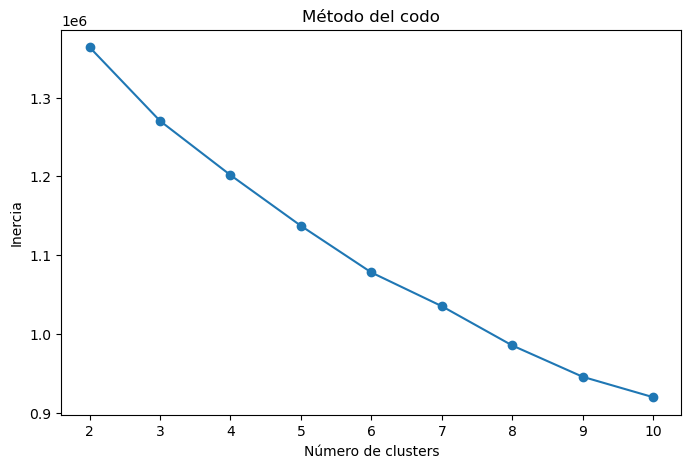

In [13]:
# MÉTODO DEL CODO PARA CONOCER EL NUMERO OPTIMOS DE CLUSTERS K
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [14]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

In [15]:
# Análisis de clústers
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
cluster,,,,,,,,,,,,,,
0,33.077565,208568.765573,0.686578,0.688443,5.457510,-6.789671,0.624258,0.088469,0.257900,0.042818,0.163904,0.665627,118.310045,3.985932
1,35.009732,261336.794315,0.487984,0.792062,5.348656,-6.134353,0.600424,0.075716,0.081971,0.220684,0.187186,0.326932,135.683374,3.933165
2,34.101029,234271.814935,0.530166,0.749281,5.314992,-7.526232,0.668940,0.188925,0.341227,0.070964,0.734347,0.499601,121.254349,3.898393
3,30.939746,215178.311878,0.453026,0.272467,4.937005,-14.817429,0.712259,0.050700,0.779687,0.323987,0.159305,0.291354,109.757074,3.690730


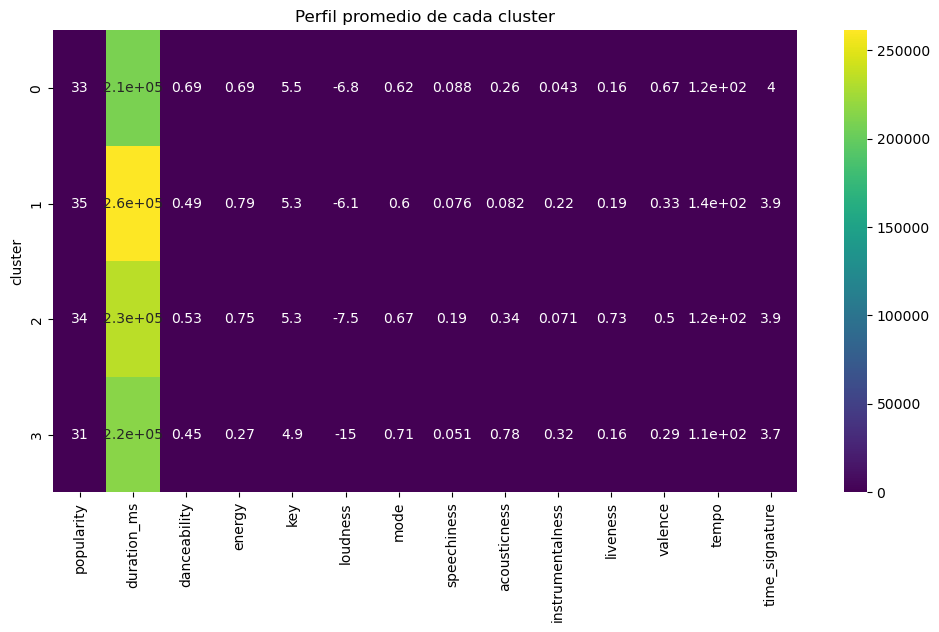

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile, annot=True, cmap="viridis")
plt.title("Perfil promedio de cada cluster")
plt.show()

## Visualización de clústers con PCA

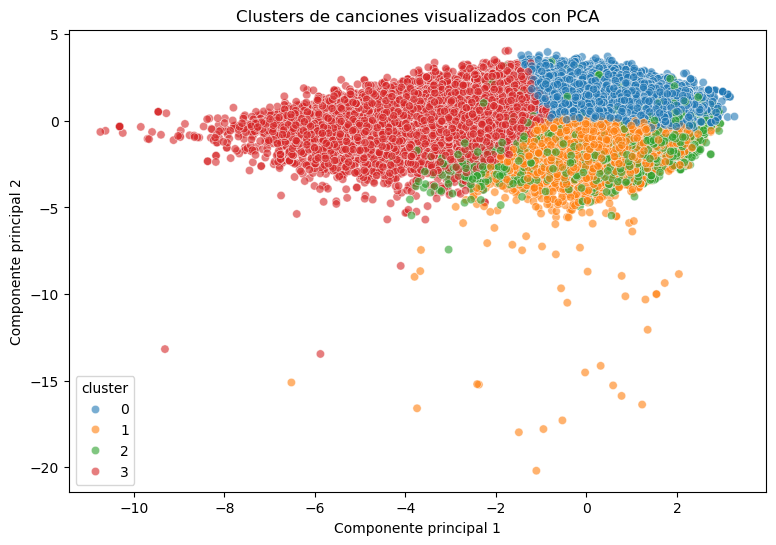

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("Clusters de canciones visualizados con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

## Varianza explicada por PCA

In [18]:
pca.explained_variance_ratio_
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

Varianza explicada total: 0.3212569935617574


## Visualizacion con t-SNE

In [19]:
from sklearn.manifold import TSNE

df_sample = df.sample(5000, random_state=42).copy()

X_sample = X_scaled[df_sample.index]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_sample)

df_sample["tsne_1"] = X_tsne[:, 0]
df_sample["tsne_2"] = X_tsne[:, 1]

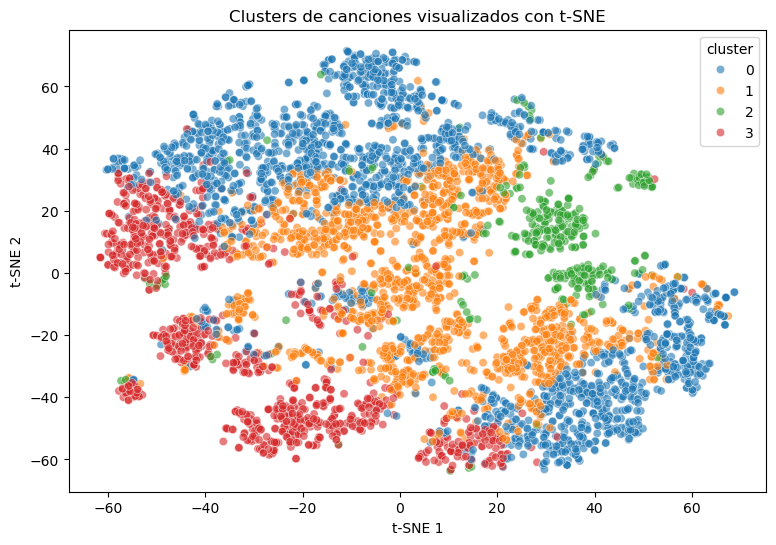

In [20]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_sample,
    x="tsne_1",
    y="tsne_2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("Clusters de canciones visualizados con t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## Géneros más frecuentes por cluster

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Conteo de géneros por clúster
conteo_generos = (
    df.groupby(["cluster", "track_genre"])
      .size()
      .reset_index(name="cantidad")
)

# Top 5 géneros más frecuentes por cada clúster
top_generos_cluster = (
    conteo_generos
    .sort_values(["cluster", "cantidad"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    .copy()
)

top_generos_cluster.head(10)

,cluster,track_genre,cantidad
89,0,reggaeton,920
68,0,latino,908
21,0,dancehall,904
88,0,reggae,902
95,0,salsa,876
135,1,death-metal,924
119,1,black-metal,908
155,1,grindcore,881
185,1,metalcore,875
140,1,drum-and-bass,832


## Visualización - géneros por clúster

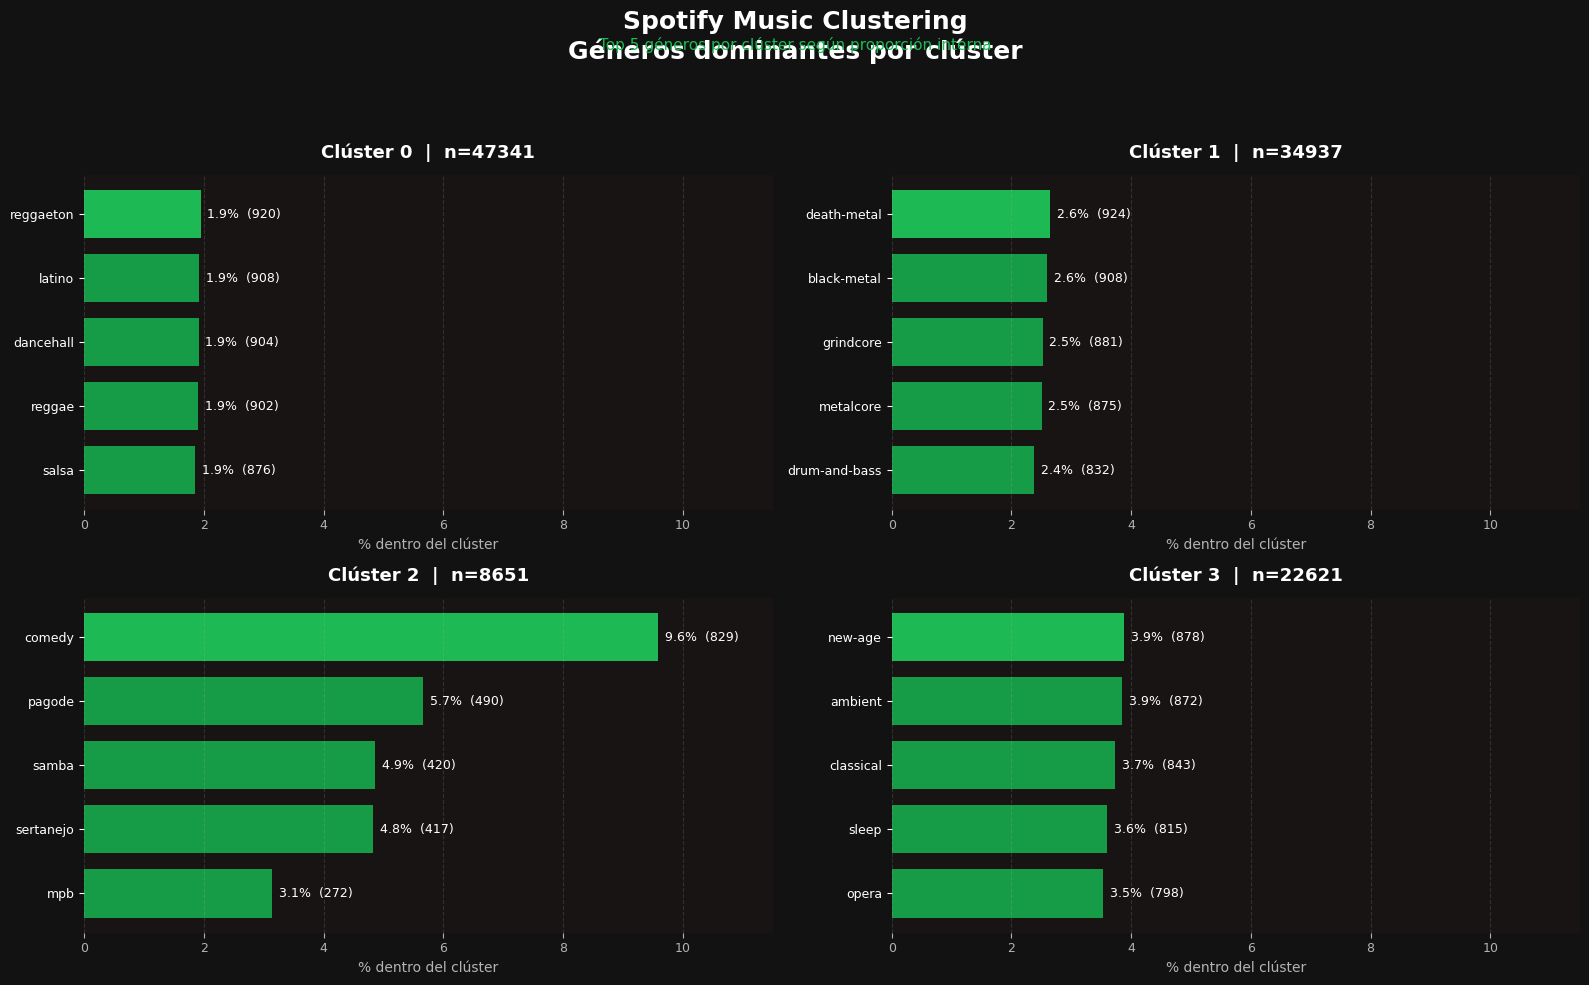

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================
# 1. Colores estilo Spotify
# =========================
spotify_green = "#1DB954"
spotify_green_dark = "#169c46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# =========================
# 2. Conteo por cluster y género
# =========================
genre_counts = (
    df.groupby(["cluster", "track_genre"])
    .size()
    .reset_index(name="count")
)

# Total de canciones por cluster
cluster_totals = (
    df.groupby("cluster")
    .size()
    .reset_index(name="total_cluster")
)

# Unir totales
genre_counts = genre_counts.merge(cluster_totals, on="cluster", how="left")

# Calcular porcentaje dentro de cada cluster
genre_counts["pct"] = (genre_counts["count"] / genre_counts["total_cluster"]) * 100

# Top 5 géneros por cluster
top_genres = (
    genre_counts
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    .copy()
)

# =========================
# 3. Preparar subplots
# =========================
clusters = sorted(top_genres["cluster"].unique())

n_cols = 2
n_rows = math.ceil(len(clusters) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
fig.patch.set_facecolor(spotify_black)

axes = axes.flatten()

# mismo límite para todos los ejes X
max_pct = top_genres["pct"].max()
x_limit = max_pct * 1.20

# =========================
# 4. Graficar cada cluster
# =========================
for ax, cluster in zip(axes, clusters):
    data_cluster = (
        top_genres[top_genres["cluster"] == cluster]
        .sort_values("pct", ascending=True)
        .copy()
    )

    # Color: resaltar barra más alta
    colors = [spotify_green_dark] * len(data_cluster)
    colors[-1] = spotify_green

    bars = ax.barh(
        data_cluster["track_genre"],
        data_cluster["pct"],
        color=colors,
        edgecolor="none",
        height=0.75
    )

    ax.set_facecolor(spotify_dark)
    ax.set_xlim(0, x_limit)

    # títulos
    total_cluster = int(data_cluster["total_cluster"].iloc[0])
    ax.set_title(
        f"Clúster {cluster}  |  n={total_cluster}",
        color=spotify_white,
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    # ejes
    ax.set_xlabel("% dentro del clúster", color=spotify_gray, fontsize=10)
    ax.set_ylabel("")
    ax.tick_params(axis="x", colors=spotify_gray, labelsize=9)
    ax.tick_params(axis="y", colors=spotify_white, labelsize=9)

    # grilla suave
    ax.xaxis.grid(True, linestyle="--", alpha=0.18, color=spotify_gray)
    ax.yaxis.grid(False)

    # limpiar bordes
    for spine in ax.spines.values():
        spine.set_visible(False)

    # etiquetas: porcentaje + conteo
    for bar, pct, cnt in zip(bars, data_cluster["pct"], data_cluster["count"]):
        ax.text(
            bar.get_width() + (x_limit * 0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  ({cnt})",
            va="center",
            ha="left",
            color=spotify_white,
            fontsize=9
        )

# eliminar ejes sobrantes
for j in range(len(clusters), len(axes)):
    fig.delaxes(axes[j])

# =========================
# 5. Título general
# =========================
plt.suptitle(
    "Spotify Music Clustering\nGéneros dominantes por clúster",
    color=spotify_white,
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5, 0.94,
    "Top 5 géneros por clúster según proporción interna",
    ha="center",
    color=spotify_green,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

- Primera versión

In [ ]:
# 1. Colores estilo Spotify

spotify_green = "#1DB954"
spotify_green_dark = "#169c46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"


# 2. Conteo por cluster y género



## Géneros más frecuentes dentro de cada clúster

Este gráfico muestra los géneros más frecuentes dentro de cada clúster en términos relativos.
Se utiliza porcentaje para facilitar la comparación entre clústeres con tamaños distintos.

In [ ]:
df.groupby("cluster")["track_genre"].value_counts().groupby(level=0).head(5)

cluster  track_genre  
0        reggaeton        920
         latino           908
         dancehall        904
         reggae           902
         salsa            876
1        death-metal      924
         black-metal      908
         grindcore        881
         metalcore        875
         drum-and-bass    832
2        comedy           829
         pagode           490
         samba            420
         sertanejo        417
         mpb              272
3        new-age          878
         ambient          872
         classical        843
         sleep            815
         opera            798
Name: count, dtype: int64

## Visualización con heatmap

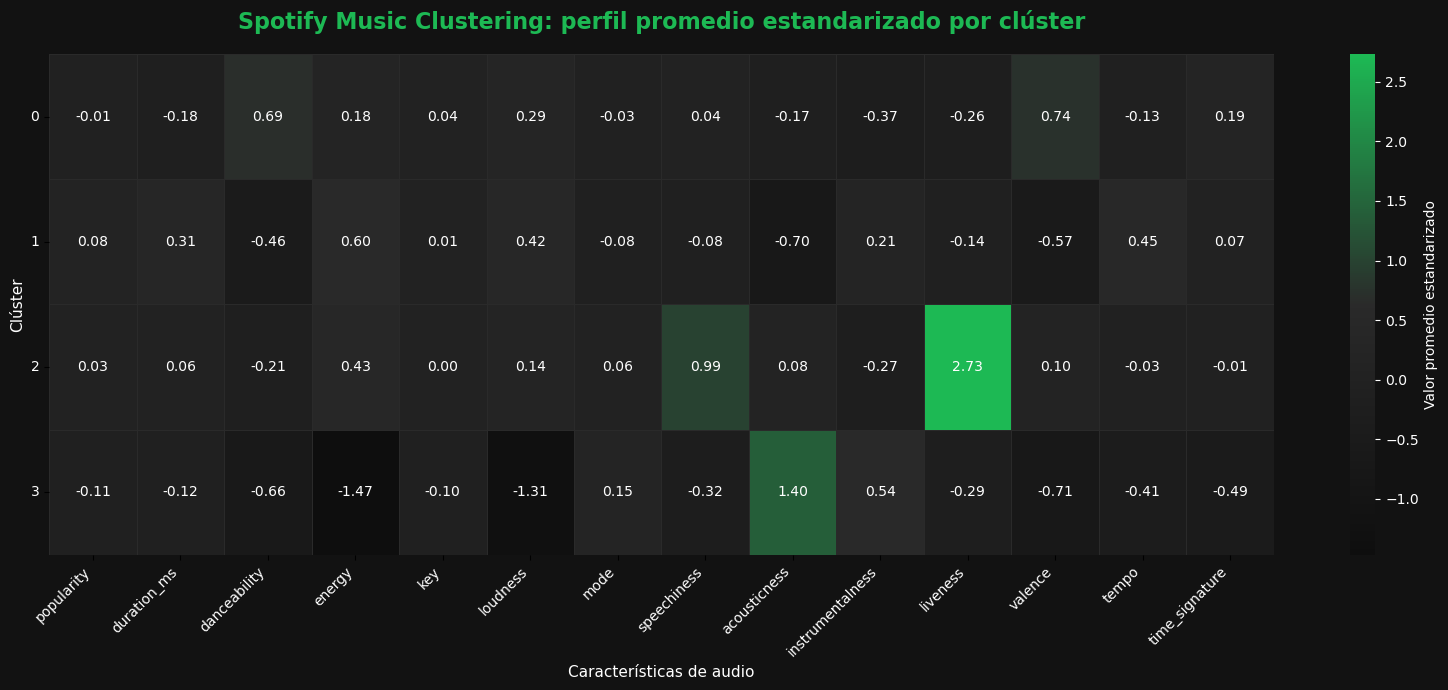

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Colores Spotify

spotify_green = "#1DB954"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"


# Variables usadas en el modelo

features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]


# Crear DataFrame escalado
# OJO: usa el mismo X_scaled que usaste para K-Means

df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled["cluster"] = df["cluster"].values

# Perfil promedio estandarizado por cluster
cluster_profile_scaled = df_scaled.groupby("cluster")[features].mean()


# Colormap estilo Spotify

spotify_cmap = LinearSegmentedColormap.from_list(
    "spotify_cmap",
    ["#0E0E0E", "#2A2A2A", spotify_green]
)


# Heatmap

plt.figure(figsize=(16, 7))
ax = sns.heatmap(
    cluster_profile_scaled,
    cmap=spotify_cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="#2A2A2A",
    cbar_kws={"label": "Valor promedio estandarizado"}
)

# Fondo
ax.set_facecolor(spotify_black)
plt.gcf().patch.set_facecolor(spotify_black)

# Títulos y etiquetas
plt.title(
    "Spotify Music Clustering: perfil promedio estandarizado por clúster",
    fontsize=16,
    fontweight="bold",
    color=spotify_green,
    pad=18
)

plt.xlabel("Características de audio", color=spotify_white, fontsize=11)
plt.ylabel("Clúster", color=spotify_white, fontsize=11)

# Ticks
plt.xticks(rotation=45, ha="right", color=spotify_white)
plt.yticks(rotation=0, color=spotify_white)

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(spotify_white)
cbar.ax.tick_params(colors=spotify_white)

plt.tight_layout()
plt.show()

## Interpretación por clúster

## Clúster 0 : Bailable / Latino / Positivo
- Este grupo tiene canciones más bailables, con mayor sensación positiva o alegre (valence) y algo más intensas que el promedio.
- Sus géneros (según el gráfico anterior) : reggaeton, latino, dancehall, reggae, salsa
- **Interpretación**: Perfil musical bailable, alegre y comercial.

---

## Clúster 1: Intenso / Metal / Alta energía
- Canciones con mayor energía, más volumen /intensidad y tempo más alto. Son menos bailables, menos acústicas y con menor valence.
- Sus géneros: death-metal, black-metal, grindcore, metalcore, drum-and-bass
- **Interpretación**¨: Perfil musical intenso, fuerte, rápido.

---

## Clúster 2: En vivo / Vocal / Spoken content
- El valor de liveness está muy por encima del promedio, sugiere canciones o pistas con sensación de presentación en vivo. Speechines alto indica mayor presencia de voz hablada o contenido vocal no necesariamente melódico.
- Sus géneros: comedy, pagode, samba, sertanejo, mpb
- **Interpretación**: Perfil de contenido en vivo, hablado, performático o con fuerte presencia vocal.

---
## Clúster 3: Acústico / Ambiental / Relajado
- Tiene alta acousticness e instrumentalness, baja energía, bajo volumen, baja bailabilidad y tempo más lento.
- Sus géneros: new-age, ambient, classical, sleep, opera
- **Interpretación**: Perfil musical acústico, instrumental, ambiental o relajado.
---

Estos resultados muestran que el modelo logró separar perfiles musicales interpretables utilizando únicamente características de audio, sin usar el género como variable de entrenamiento.

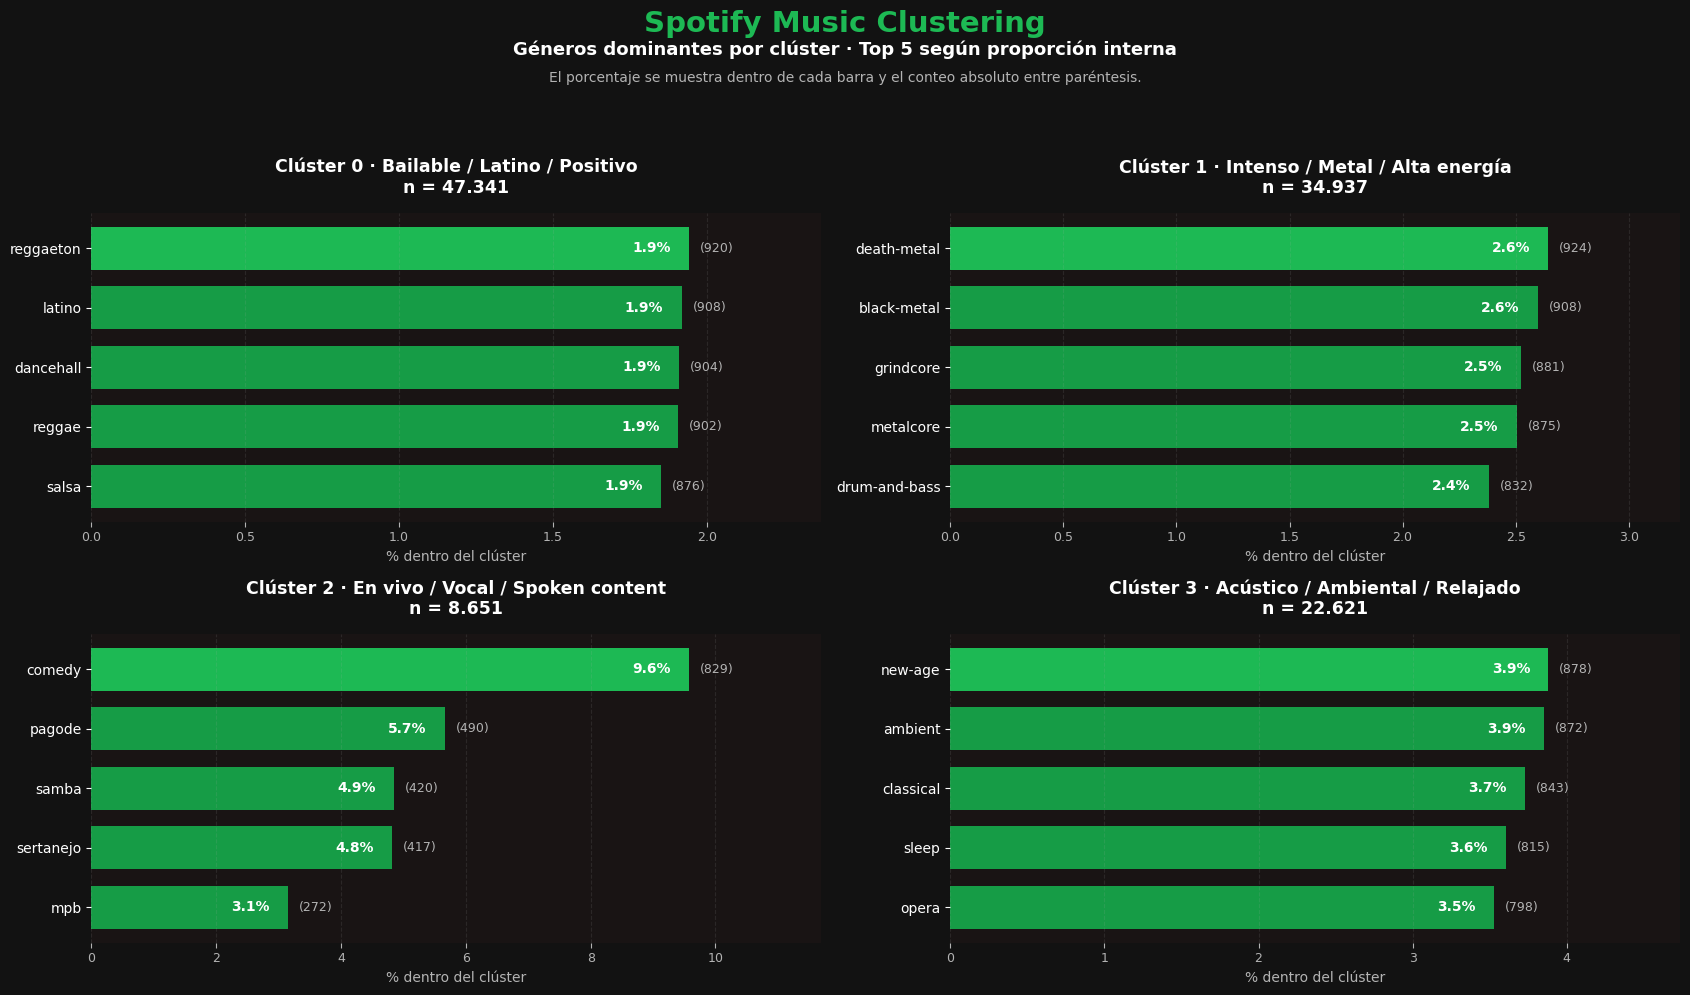

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Colores estilo Spotify
spotify_green = "#1DB954"
spotify_green_dark = "#169c46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# 2. Nombres interpretativos de clusters
cluster_names = {
    0: "Bailable / Latino / Positivo",
    1: "Intenso / Metal / Alta energía",
    2: "En vivo / Vocal / Spoken content",
    3: "Acústico / Ambiental / Relajado"
}

# 3. Conteo por cluster y género
genre_counts = (
    df.groupby(["cluster", "track_genre"])
    .size()
    .reset_index(name="count")
)

cluster_totals = (
    df.groupby("cluster")
    .size()
    .reset_index(name="total_cluster")
)

genre_counts = genre_counts.merge(cluster_totals, on="cluster", how="left")
genre_counts["pct"] = (genre_counts["count"] / genre_counts["total_cluster"]) * 100

top_genres = (
    genre_counts
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    .copy()
)

# 4. Preparar subplots
clusters = sorted(top_genres["cluster"].unique())

n_cols = 2
n_rows = math.ceil(len(clusters) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10))
fig.patch.set_facecolor(spotify_black)

axes = axes.flatten()


# 5. Graficar cada cluster
for ax, cluster in zip(axes, clusters):
    data_cluster = (
        top_genres[top_genres["cluster"] == cluster]
        .sort_values("pct", ascending=True)
        .copy()
    )

    # Escala local por clúster
    local_max_pct = data_cluster["pct"].max()
    x_limit = local_max_pct * 1.22

    colors = [spotify_green_dark] * len(data_cluster)
    colors[-1] = spotify_green

    bars = ax.barh(
        data_cluster["track_genre"],
        data_cluster["pct"],
        color=colors,
        edgecolor="none",
        height=0.72
    )

    ax.set_facecolor(spotify_dark)
    ax.set_xlim(0, x_limit)

    total_cluster = int(data_cluster["total_cluster"].iloc[0])
    cluster_title = cluster_names.get(cluster, f"Clúster {cluster}")

    ax.set_title(
        f"Clúster {cluster} · {cluster_title}\n"
        f"n = {total_cluster:,}".replace(",", "."),
        color=spotify_white,
        fontsize=12.5,
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel("% dentro del clúster", color=spotify_gray, fontsize=10)
    ax.set_ylabel("")

    ax.tick_params(axis="x", colors=spotify_gray, labelsize=9)
    ax.tick_params(axis="y", colors=spotify_white, labelsize=10)

    ax.xaxis.grid(True, linestyle="--", alpha=0.12, color=spotify_gray)
    ax.yaxis.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    
    # Etiquetas dentro de la barra
    for bar, pct, cnt in zip(bars, data_cluster["pct"], data_cluster["count"]):
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        # Porcentaje dentro de la barra
        ax.text(
            width - (x_limit * 0.025),
            y_pos,
            f"{pct:.1f}%",
            va="center",
            ha="right",
            color=spotify_white,
            fontsize=10,
            fontweight="bold"
        )

        # Conteo fuera de la barra
        ax.text(
            width + (x_limit * 0.015),
            y_pos,
            f"({cnt})",
            va="center",
            ha="left",
            color=spotify_gray,
            fontsize=9
        )

# Eliminar subplots vacíos
for j in range(len(clusters), len(axes)):
    fig.delaxes(axes[j])


# 6. Título general
plt.suptitle(
    "Spotify Music Clustering",
    color=spotify_green,
    fontsize=21,
    fontweight="bold",
    y=0.99
)

fig.text(
    0.5, 0.945,
    "Géneros dominantes por clúster · Top 5 según proporción interna",
    ha="center",
    color=spotify_white,
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.5, 0.918,
    "El porcentaje se muestra dentro de cada barra y el conteo absoluto entre paréntesis.",
    ha="center",
    color=spotify_gray,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

Para mejorar la legibilidad, cada subplot utiliza una escala local en el eje X. 
Las etiquetas muestran el porcentaje real de cada género dentro del clúster, junto con la cantidad de canciones correspondiente.

In [44]:
df[["track_name", "artists", "track_genre", "popularity", "cluster"]].sort_values(
    ["cluster", "popularity"],
    ascending=[True, False]
).groupby("cluster").head(5)

,track_name,artists,track_genre,popularity,cluster
51449,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99,0
67072,La Bachata,Manuel Turizo,latin,98,0
68010,La Bachata,Manuel Turizo,latino,98,0
88069,La Bachata,Manuel Turizo,reggae,98,0
89070,La Bachata,Manuel Turizo,reggaeton,98,0
19904,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,1
80727,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100,1
19911,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98,1
29858,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98,1
80885,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98,1


In [23]:
from IPython.display import display, HTML
import html

# =========================
# Colores Spotify
# =========================
spotify_green = "#1DB954"
spotify_green_dark = "#169C46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_dark_2 = "#0E0E0E"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# =========================
# Nombres interpretativos de clúster
# =========================
cluster_names = {
    0: "Bailable / Latino / Positivo",
    1: "Intenso / Metal / Alta energía",
    2: "En vivo / Vocal / Spoken content",
    3: "Acústico / Ambiental / Relajado"
}

# =========================
# Top 5 canciones por clúster
# =========================
top_tracks = (
    df[["track_name", "artists", "track_genre", "popularity", "cluster"]]
    .dropna(subset=["track_name", "artists", "track_genre", "popularity", "cluster"])
    .drop_duplicates(subset=["cluster", "track_name", "artists"])
    .sort_values(["cluster", "popularity"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    .copy()
)

top_tracks["rank"] = top_tracks.groupby("cluster").cumcount() + 1

top_tracks["cluster_label"] = (
    "Clúster "
    + top_tracks["cluster"].astype(int).astype(str)
    + " · "
    + top_tracks["cluster"].map(cluster_names)
)

top_tracks_view = top_tracks[
    ["cluster_label", "rank", "track_name", "artists", "track_genre", "popularity"]
].rename(columns={
    "cluster_label": "Clúster",
    "rank": "#",
    "track_name": "Canción",
    "artists": "Artista",
    "track_genre": "Género",
    "popularity": "Popularidad"
})

# =========================
# Normalización visual de popularidad
# =========================
min_pop = top_tracks_view["Popularidad"].min()
max_pop = top_tracks_view["Popularidad"].max()

def popularity_bar(value):
    value = float(value)

    if max_pop == min_pop:
        width = 100
    else:
        width = 18 + ((value - min_pop) / (max_pop - min_pop)) * 82

    return f"""
    <div style="display:flex; align-items:center; gap:10px;">
        <span style="
            min-width:36px;
            font-weight:800;
            color:{spotify_white};
            text-align:right;
        ">{value:.0f}</span>

        <div style="
            width:115px;
            height:10px;
            background-color:#2A2A2A;
            border-radius:999px;
            overflow:hidden;
        ">
            <div style="
                width:{width:.1f}%;
                height:100%;
                background:linear-gradient(90deg, {spotify_green_dark}, {spotify_green});
                border-radius:999px;
            "></div>
        </div>
    </div>
    """

# =========================
# Crear tabla HTML
# =========================
html_table = f"""
<style>
.spotify-table {{
    width: 100%;
    border-collapse: collapse;
    background-color: {spotify_black};
    color: {spotify_white};
    font-family: Arial, sans-serif;
    font-size: 13px;
}}

.spotify-table caption {{
    caption-side: top;
    text-align: left;
    color: {spotify_green};
    font-size: 18px;
    font-weight: 800;
    padding: 12px 0;
}}

.spotify-table th {{
    background-color: {spotify_green};
    color: {spotify_black};
    padding: 11px 10px;
    text-align: left;
    font-weight: 800;
}}

.spotify-table td {{
    padding: 10px;
    border-bottom: 1px solid #252525;
    vertical-align: middle;
}}

.spotify-table tr:nth-child(even) {{
    background-color: {spotify_dark};
}}

.spotify-table tr:nth-child(odd) {{
    background-color: {spotify_dark_2};
}}

.spotify-table tr:hover {{
    background-color: #202020;
}}

.cluster-pill {{
    display: inline-block;
    background-color: {spotify_green};
    color: {spotify_black};
    font-weight: 800;
    text-align: center;
    border-radius: 999px;
    padding: 6px 10px;
    font-size: 12px;
    white-space: nowrap;
}}

.rank-cell {{
    text-align: center;
    color: {spotify_gray};
    font-weight: 700;
}}

.genre-pill {{
    display: inline-block;
    background-color: #2A2A2A;
    color: {spotify_white};
    padding: 4px 8px;
    border-radius: 999px;
    font-size: 12px;
}}

.track-name {{
    font-weight: 700;
    color: {spotify_white};
}}

.artist-name {{
    color: {spotify_gray};
}}
</style>

<table class="spotify-table">
<caption>Spotify Music Clustering: canciones más populares por clúster</caption>
<thead>
<tr>
    <th>Clúster</th>
    <th style="text-align:center;">#</th>
    <th>Canción</th>
    <th>Artista</th>
    <th>Género</th>
    <th>Popularidad</th>
</tr>
</thead>
<tbody>
"""

for _, row in top_tracks_view.iterrows():
    html_table += f"""
    <tr>
        <td style="text-align:left;">
            <span class="cluster-pill">{html.escape(str(row["Clúster"]))}</span>
        </td>
        <td class="rank-cell">{int(row["#"])}</td>
        <td class="track-name">{html.escape(str(row["Canción"]))}</td>
        <td class="artist-name">{html.escape(str(row["Artista"]))}</td>
        <td><span class="genre-pill">{html.escape(str(row["Género"]))}</span></td>
        <td>{popularity_bar(row["Popularidad"])}</td>
    </tr>
    """

html_table += """
</tbody>
</table>
"""

display(HTML(html_table))
# Guardar imagen
from html2image import Html2Image
import os

# Crear carpeta para imágenes si no existe
os.makedirs("images", exist_ok=True)

# Configurar salida
hti = Html2Image(output_path="images")

# Guardar tabla como imagen
hti.screenshot(
    html_str=html_table,
    save_as="top_tracks_by_cluster.png",
    size=(1900, 1400)
)

Clúster,#,Canción,Artista,Género,Popularidad
Clúster 0 · Bailable / Latino / Positivo,1,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
Clúster 0 · Bailable / Latino / Positivo,2,La Bachata,Manuel Turizo,latin,98
Clúster 0 · Bailable / Latino / Positivo,3,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97
Clúster 0 · Bailable / Latino / Positivo,4,Under The Influence,Chris Brown,dance,96
Clúster 0 · Bailable / Latino / Positivo,5,Efecto,Bad Bunny,latin,96
Clúster 1 · Intenso / Metal / Alta energía,1,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
Clúster 1 · Intenso / Metal / Alta energía,2,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
Clúster 1 · Intenso / Metal / Alta energía,3,Tití Me Preguntó,Bad Bunny,latin,97
Clúster 1 · Intenso / Metal / Alta energía,4,As It Was,Harry Styles,pop,95
Clúster 1 · Intenso / Metal / Alta energía,5,Sweater Weather,The Neighbourhood,alt-rock,93


['c:\\Users\\ireli\\Desktop\\PROYECTOS\\SpotifyMusicClustering\\images\\top_tracks_by_cluster.png']

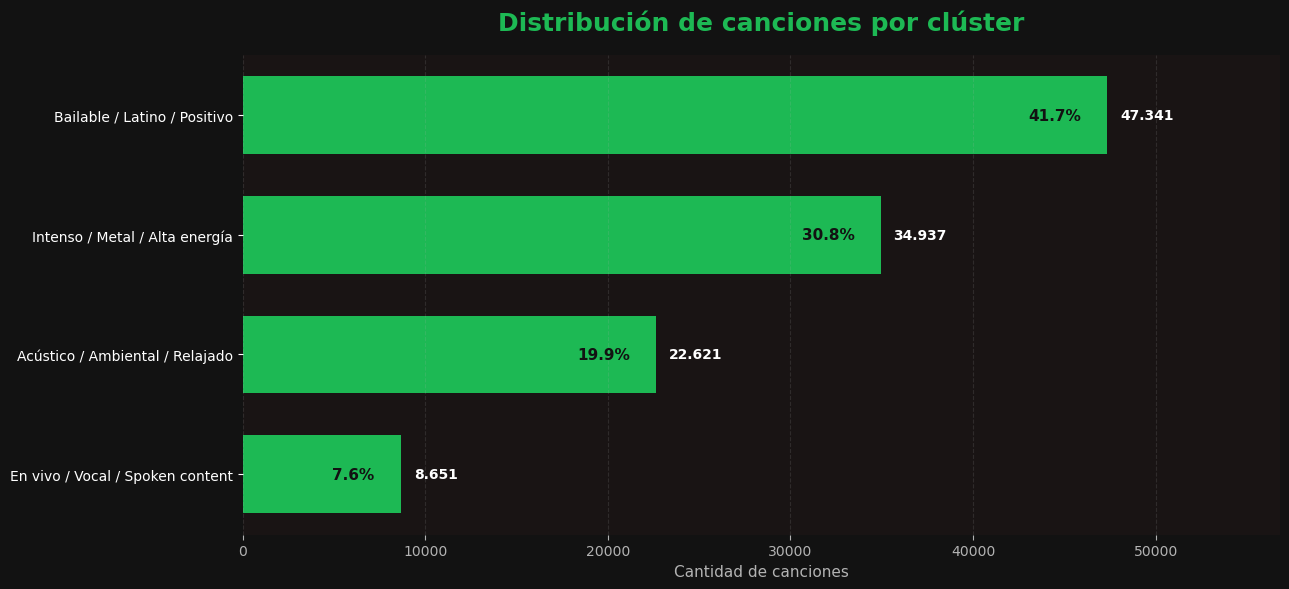

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Colores Spotify
# =========================
spotify_green = "#1DB954"
spotify_green_dark = "#169c46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# =========================
# Nombres interpretativos de clúster
# =========================
cluster_names = {
    0: "Bailable / Latino / Positivo",
    1: "Intenso / Metal / Alta energía",
    2: "En vivo / Vocal / Spoken content",
    3: "Acústico / Ambiental / Relajado"
}

# =========================
# Conteo por clúster
# =========================
cluster_size = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_size.columns = ["cluster", "count"]
cluster_size["cluster_name"] = cluster_size["cluster"].map(cluster_names)
cluster_size["pct"] = (cluster_size["count"] / cluster_size["count"].sum()) * 100

cluster_size = cluster_size.sort_values("count", ascending=True)

# =========================
# Gráfico
# =========================
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bars = ax.barh(
    cluster_size["cluster_name"],
    cluster_size["count"],
    color=spotify_green,
    height=0.65
)

max_count = cluster_size["count"].max()
ax.set_xlim(0, max_count * 1.20)

# Etiquetas
for bar, count, pct in zip(bars, cluster_size["count"], cluster_size["pct"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    ax.text(
        width - (max_count * 0.03),
        y_pos,
        f"{pct:.1f}%",
        va="center",
        ha="right",
        color=spotify_black,
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        width + (max_count * 0.015),
        y_pos,
        f"{count:,}".replace(",", "."),
        va="center",
        ha="left",
        color=spotify_white,
        fontsize=10,
        fontweight="bold"
    )

# Estilo
ax.set_title(
    "Distribución de canciones por clúster",
    color=spotify_green,
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Cantidad de canciones", color=spotify_gray, fontsize=11)
ax.set_ylabel("")

ax.tick_params(axis="x", colors=spotify_gray)
ax.tick_params(axis="y", colors=spotify_white, labelsize=10)

ax.xaxis.grid(True, linestyle="--", alpha=0.15, color=spotify_gray)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Radar chart por clúster

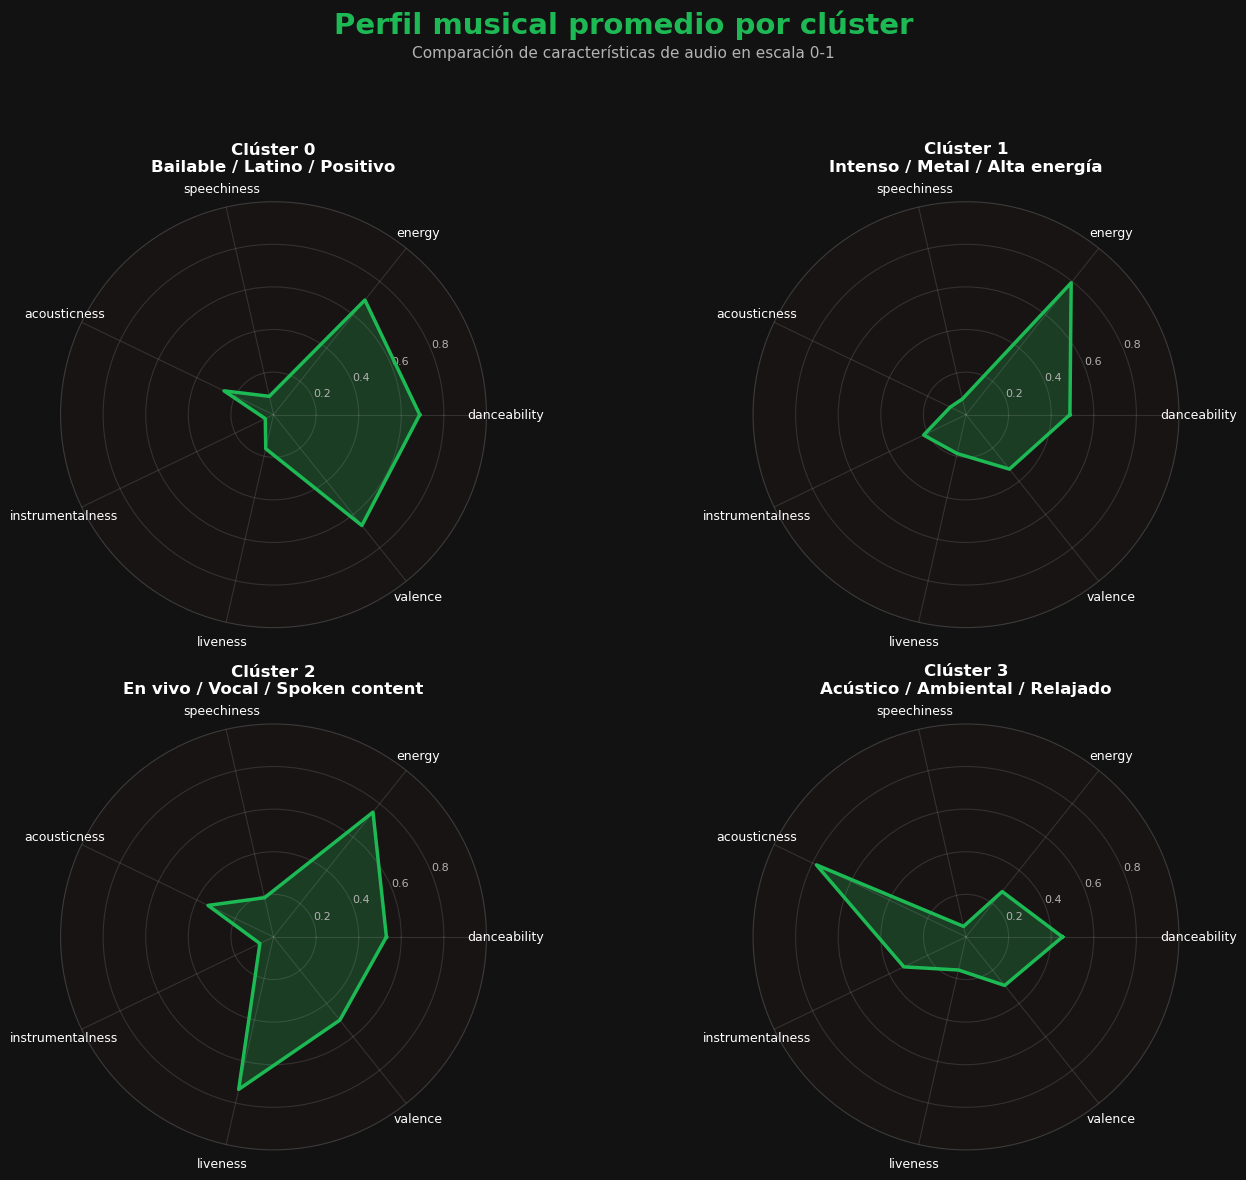

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Colores Spotify
# =========================
spotify_green = "#1DB954"
spotify_green_dark = "#169c46"
spotify_black = "#121212"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# =========================
# Nombres interpretativos de clúster
# =========================
cluster_names = {
    0: "Bailable / Latino / Positivo",
    1: "Intenso / Metal / Alta energía",
    2: "En vivo / Vocal / Spoken content",
    3: "Acústico / Ambiental / Relajado"
}

# =========================
# Variables más interpretables
# Estas variables ya están en escala 0-1 en el dataset
# =========================
radar_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

# Perfil promedio real por clúster
radar_profile = (
    df.groupby("cluster")[radar_features]
    .mean()
    .reset_index()
)

# =========================
# Preparar radar
# =========================
labels = radar_features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

clusters = sorted(radar_profile["cluster"].unique())

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 12),
    subplot_kw=dict(polar=True)
)

fig.patch.set_facecolor(spotify_black)
axes = axes.flatten()

# =========================
# Crear gráfico por clúster
# =========================
for ax, cluster in zip(axes, clusters):
    values = (
        radar_profile[radar_profile["cluster"] == cluster][radar_features]
        .values
        .flatten()
        .tolist()
    )

    values += values[:1]

    ax.set_facecolor(spotify_dark)

    ax.plot(
        angles,
        values,
        color=spotify_green,
        linewidth=2.5
    )

    ax.fill(
        angles,
        values,
        color=spotify_green,
        alpha=0.25
    )

    ax.set_title(
        f"Clúster {cluster}\n{cluster_names.get(cluster, '')}",
        color=spotify_white,
        fontsize=12,
        fontweight="bold",
        pad=22
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, color=spotify_white, fontsize=9)

    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color=spotify_gray, fontsize=8)

    ax.set_ylim(0, 1)

    ax.grid(color=spotify_gray, alpha=0.18)
    ax.spines["polar"].set_color(spotify_gray)
    ax.spines["polar"].set_alpha(0.25)

# Eliminar ejes vacíos si sobran
for j in range(len(clusters), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Perfil musical promedio por clúster",
    color=spotify_green,
    fontsize=21,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.94,
    "Comparación de características de audio en escala 0-1",
    ha="center",
    color=spotify_gray,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

El radar chart permite comparar visualmente el perfil musical de cada clúster. 
Cada eje representa una característica de audio en escala 0-1, lo que facilita identificar diferencias entre canciones bailables, intensas, acústicas, instrumentales o con mayor presencia vocal.

## Conclusión general

En este proyecto se aplicó aprendizaje de máquina no supervisado para segmentar canciones de Spotify según sus características de audio.

A partir de variables como danceability, energy, acousticness, instrumentalness, liveness, speechiness y valence, se entrenó un modelo K-Means que permitió identificar cuatro perfiles musicales diferenciados.

La reducción dimensional mediante PCA y t-SNE permitió visualizar la estructura de los grupos, mientras que el heatmap, el análisis de géneros dominantes, las canciones más populares y los radar charts facilitaron la interpretación musical de cada clúster.

Los resultados muestran que el modelo logró separar canciones en perfiles coherentes, tales como canciones bailables y positivas, canciones intensas de alta energía, canciones con mayor presencia vocal o en vivo, y canciones acústicas, ambientales o relajadas.

Este tipo de análisis puede utilizarse como base para sistemas de recomendación musical, segmentación de catálogos, creación automática de playlists o exploración de patrones musicales en grandes volúmenes de datos.